<a href="https://colab.research.google.com/github/mai890107/mai890107/blob/main/K%E7%B7%9A%E5%9C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.2 MB/s eta 0:00:00
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


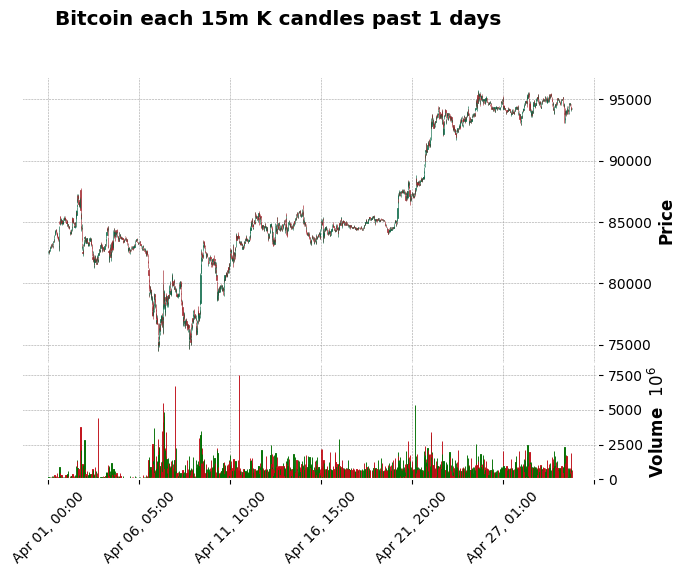

In [ ]:
import yfinance as yf
!pip install mplfinance
import mplfinance as mpf
import pandas as pd
from datetime import datetime, timedelta


# 設定時間範圍
end_time = datetime.now()
start_time = end_time - timedelta(days=30)

# 下載 BTC 每30分鐘資料，使用 group_by='ticker' 會造成 MultiIndex
btc_data = yf.download("BTC-USD", interval="15m", start=start_time.strftime('%Y-%m-%d'), end=end_time.strftime('%Y-%m-%d'), group_by='column')

# 將 MultiIndex 欄位轉換成單層（取出 BTC-USD 那層）
btc_data.columns = btc_data.columns.droplevel(1)

# 篩選需要欄位
btc_data = btc_data[['Open', 'High', 'Low', 'Close', 'Volume']]

# 移除 NaN
btc_data.dropna(inplace=True)

# 強制轉型成 float
btc_data = btc_data.astype(float)

time_list = btc_data.index.to_list()
btc_data['Time'] = time_list
btc_data_include_time = btc_data[['Time','Open', 'High', 'Low', 'Close', 'Volume']]

# 確保 index 為 datetime
btc_data.index = pd.to_datetime(btc_data.index)

# 畫出 K 線圖
mpf.plot(btc_data, type='candle', style='charles', volume=True, title='Bitcoin each 15m K candles past 1 days')

In [ ]:
def detect_bos(df, lookback, vol_factor=0):
    """
    BOS 偵測（新增時間間隔限制 ≥ 30分鐘）：
    - lookback: 前 N 根 K 棒
    - vol_factor: 成交量濾波
    - BOS 間時間間隔 ≥ 30 分鐘
    """
    highs   = df['High']
    lows    = df['Low']
    closes  = df['Close']
    vols    = df['Volume']
    avg_vol = vols.rolling(lookback).mean()

    signal = pd.Series(0, index=df.index)
    last_bos_index = None

    for i in range(lookback, len(df)):
        if last_bos_index is not None:
            time_diff = (df.index[i] - df.index[last_bos_index]).total_seconds() / 60
            if time_diff < 30:
                continue

        prev_high = highs[i-lookback:i].max()
        prev_low  = lows[i-lookback:i].min()
        cur_close = closes.iloc[i]
        cur_vol   = vols.iloc[i]

        if cur_close > prev_high and cur_vol > avg_vol.iloc[i] * vol_factor:
            signal.iloc[i] = 1
            last_bos_index = i
        elif cur_close < prev_low and cur_vol > avg_vol.iloc[i] * vol_factor:
            signal.iloc[i] = -1
            last_bos_index = i

    return signal

# 版本1 MSS

In [ ]:
def detect_mss(df, bos_sig, lookback, debug=True):
    """
    MSS 偵測（修正版）

    - 多頭 BOS：成本區為 BOS 前 lookback 根 K 棒的最低點
    - 空頭 BOS：成本區為 BOS 前 lookback 根 K 棒的最高點
    - MSS 條件：
        - 多頭 BOS → 價格跌破成本區 → MSS = -1（多轉空）
        - 空頭 BOS → 價格突破成本區 → MSS = +1（空轉多）
    - 修正重點：
        - 先判斷是否觸發 MSS，再判斷是否遇到新 BOS 才停止掃描
    """
    lows    = df['Low']
    highs   = df['High']
    closes  = df['Close']
    mss_sig = pd.Series(0, index=df.index)

    # 找出所有 BOS 發生位置
    bos_idx = [i for i, v in enumerate(bos_sig.values) if v != 0]

    for pos in bos_idx:
        if pos < lookback:
            continue  # 若前 lookback 根資料不足，跳過

        is_long = bos_sig.iloc[pos] == 1
        cost_zone = lows.iloc[pos - lookback:pos].min() if is_long else highs.iloc[pos - lookback:pos].max()

        if debug:
            direction = '多頭 BOS' if is_long else '空頭 BOS'
            print(f"\n[BOS @ {pos}] → {direction}，成本區 = {cost_zone:.2f}")

        # 從 BOS 發生後一根開始掃描
        for j in range(pos + 1, len(df)):
            price = closes.iloc[j]

            # ✅ Step 1：先判斷 MSS 是否觸發
            if is_long and price < cost_zone:
                mss_sig.iloc[j] = -1
                if debug:
                    print(f"→ MSS = -1 @ {j}, 收盤價 {price:.2f} 跌破成本區 {cost_zone:.2f}")
                break
            elif (not is_long) and price > cost_zone:
                mss_sig.iloc[j] = 1
                if debug:
                    print(f"→ MSS = +1 @ {j}, 收盤價 {price:.2f} 突破成本區 {cost_zone:.2f}")
                break

            # ✅ Step 2：若遇到下一個 BOS，則停止掃描
            if bos_sig.iloc[j] != 0:
                if debug:
                    print(f"→ BOS @ {j} 出現，掃描終止（未觸發 MSS）")
                break

    return mss_sig



版本1 改版

In [ ]:
def detect_mss(df, bos_sig, lookback, debug=True):
    lows    = df['Low']
    highs   = df['High']
    closes  = df['Close']
    mss_sig = pd.Series(0, index=df.index)

    bos_idx = [i for i, v in enumerate(bos_sig.values) if v != 0]
    for pos in bos_idx:
        if pos < lookback: continue

        is_long   = bos_sig.iloc[pos] == 1
        cost_zone = (lows if is_long else highs) \
                      .iloc[pos-lookback:pos] \
                      .agg('min' if is_long else 'max')

        if debug:
            d = '多頭 BOS' if is_long else '空頭 BOS'
            print(f"[BOS @ {pos}] {d}，成本區={cost_zone:.2f}")

        for j in range(pos+1, len(df)):
            price = closes.iloc[j]

            # 1) MSS 觸發條件
            if is_long and price < cost_zone:
                mss_sig.iloc[j] = -1
                if debug: print(f"→ MSS=-1 @ {j}（收盤 {price:.2f} 跌破 {cost_zone:.2f}）")
                break
            if not is_long and price > cost_zone:
                mss_sig.iloc[j] = 1
                if debug: print(f"→ MSS=+1 @ {j}（收盤 {price:.2f} 突破 {cost_zone:.2f}）")
                break

            # 2) 只有遇到「反向 BOS」才停止掃描
            if bos_sig.iloc[j] != 0 and bos_sig.iloc[j] != bos_sig.iloc[pos]:
                if debug: print(f"→ 反向 BOS @ {j}，停止對 {pos} 的掃描")
                break

    return mss_sig


# verion 2 MSS 須連續突破2個價格

In [ ]:
def detect_mss(df, bos_sig, lookback, debug=True):
    """
    MSS 偵測（升級版：收盤兩連破成本區確認）

    - 多頭 BOS：成本區為前 lookback 根最低點
    - 空頭 BOS：成本區為前 lookback 根最高點
    - MSS 條件：
        - 多頭 BOS ➔ 收盤價連續兩根都跌破成本區 ➔ MSS = -1（多轉空）
        - 空頭 BOS ➔ 收盤價連續兩根都突破成本區 ➔ MSS = +1（空轉多）
    - 每個 BOS 最多一個 MSS
    - 遇到新的 BOS 停止掃描
    """
    lows   = df['Low']
    highs  = df['High']
    closes = df['Close']
    mss_sig = pd.Series(0, index=df.index)

    bos_idx = [i for i, v in enumerate(bos_sig.values) if v != 0]

    for pos in bos_idx:
        if pos < lookback:
            continue

        is_long = bos_sig.iloc[pos] == 1
        cost_zone = lows.iloc[pos - lookback:pos].min() if is_long else highs.iloc[pos - lookback:pos].max()

        consecutive = 0  # 連續突破計數器

        for j in range(pos + 1, len(df)):
            price = closes.iloc[j]

            if is_long and price < cost_zone:
                consecutive += 1
            elif not is_long and price > cost_zone:
                consecutive += 1
            else:
                consecutive = 0  # 如果沒連續，歸零

            # ✅ 連續兩根都突破後，確定 MSS
            if consecutive >= 2:
                mss_sig.iloc[j] = -1 if is_long else 1
                if debug:
                    print(f"[MSS {'-1' if is_long else '+1'}] @ {j}, close={price}, cost_zone={cost_zone}")
                break

            # ✅ 如果遇到新的 BOS，停止掃描
            if bos_sig.iloc[j] != 0:
                break

    return mss_sig


# Verion 3 不須連續突破2個價格

In [ ]:
def detect_mss(df, bos_sig, lookback, debug=True):
    """
    MSS 偵測（靈活版：兩根內累積突破，不一定要連續）

    - 多頭 BOS：成本區為前 lookback 根最低點
    - 空頭 BOS：成本區為前 lookback 根最高點
    - MSS 條件：
        - BOS後，往後掃描
        - 只要2根內有2次破成本區，就確認 MSS
    - 遇到 MSS 才停止；遇到 BOS 不會立刻停止（MSS優先）
    """
    lows   = df['Low']
    highs  = df['High']
    closes = df['Close']
    mss_sig = pd.Series(0, index=df.index)

    bos_idx = [i for i, v in enumerate(bos_sig.values) if v != 0]

    for pos in bos_idx:
        if pos < lookback:
            continue

        is_long = bos_sig.iloc[pos] == 1
        cost_zone = lows.iloc[pos - lookback:pos].min() if is_long else highs.iloc[pos - lookback:pos].max()

        consecutive = 0  # 累積突破次數

        for j in range(pos + 1, len(df)):
            price = closes.iloc[j]

            if is_long and price < cost_zone:
                consecutive += 1
            elif not is_long and price > cost_zone:
                consecutive += 1

            # ✅ 累積2次突破就標 MSS
            if consecutive >= 2:
                mss_sig.iloc[j] = -1 if is_long else 1
                if debug:
                    print(f"[MSS {'-1' if is_long else '+1'}] @ {j}, close={price}, cost_zone={cost_zone}")
                break



    return mss_sig


In [ ]:

def plot_bos_mss(
    df,
    title='Bitcoin 每30分鐘 K 線圖：BOS ＋ MSS',
    bos_lookback=10,
    mss_lookback=1,
    circle_color='#3B82F6',   # MSS 標記顏色 (Tailwind sky‑500)
    circle_size=12
):
    # ────────────────────────────────────────
    # 1) 偵測 BOS 與 MSS
    bos_sig = detect_bos(df, bos_lookback)
    mss_sig = detect_mss(df, bos_sig, mss_lookback,debug=False)

    # ────────────────────────────────────────
    # 2) 建立子圖：K 線 + 成交量
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        row_heights=[0.75, 0.25],
        vertical_spacing=0.02,
        specs=[[{"type": "candlestick"}], [{"type": "bar"}]]
    )

    # ────────────────────────────────────────
    # 3) 畫 K 線
    fig.add_trace(go.Candlestick(
        x=df.index,
        open=df['Open'], high=df['High'],
        low=df['Low'], close=df['Close'],
        name='Price'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 4) 畫 BOS 標記
    up_idx = bos_sig[bos_sig == 1].index
    dn_idx = bos_sig[bos_sig == -1].index

    fig.add_trace(go.Scatter(
        x=up_idx,
        y=df.loc[up_idx, 'High'] * 1.002,
        mode='markers',
        marker_symbol='triangle-up',
        marker_color='green',
        marker_size=12,
        name='BOS ↑'
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=dn_idx,
        y=df.loc[dn_idx, 'Low'] * 0.998,
        mode='markers',
        marker_symbol='triangle-down',
        marker_color='red',
        marker_size=12,
        name='BOS ↓'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 5) 畫 MSS 標記（單一藍色圓圈）
    mss_idx = mss_sig[mss_sig != 0].index
    # 依方向微調 y 位置，避免被蠟燭遮住
    y_coord = [
        df.loc[i, 'Low'] * 0.995 if mss_sig.loc[i] == 1
        else df.loc[i, 'High'] * 1.005
        for i in mss_idx
    ]

    fig.add_trace(go.Scatter(
        x=mss_idx,
        y=y_coord,
        mode='markers',
        marker_symbol='circle',
        marker_color=circle_color,
        marker_size=circle_size,
        marker_line=dict(width=1, color='white'),
        name='MSS'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 6) 畫成交量
    vol_colors = ['green' if c > o else 'red'
                  for o, c in zip(df['Open'], df['Close'])]
    fig.add_trace(go.Bar(
        x=df.index,
        y=df['Volume'],
        marker_color=vol_colors,
        name='Volume',
        opacity=0.5
    ), row=2, col=1)

    # ────────────────────────────────────────
    # 7) 版面調整
    fig.update_layout(
        title=title,
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=700
    )
    fig.update_yaxes(title_text='Price', row=1, col=1)
    fig.update_yaxes(title_text='Volume', row=2, col=1)

    return fig

In [ ]:

bos_sig = detect_bos(btc_data, lookback=10 )
mss_sig = detect_mss(btc_data, bos_sig=bos_sig, lookback=1,debug=True)


fig = plot_bos_mss(btc_data, bos_lookback=10, mss_lookback=1)
fig.show()



[BOS @ 11] → 多頭 BOS，成本區 = 82781.18
→ BOS @ 21 出現，掃描終止（未觸發 MSS）

[BOS @ 21] → 多頭 BOS，成本區 = 82999.13
→ MSS = -1 @ 24, 收盤價 82927.98 跌破成本區 82999.13

[BOS @ 26] → 多頭 BOS，成本區 = 82962.79
→ BOS @ 28 出現，掃描終止（未觸發 MSS）

[BOS @ 28] → 多頭 BOS，成本區 = 83308.93
→ BOS @ 30 出現，掃描終止（未觸發 MSS）

[BOS @ 30] → 多頭 BOS，成本區 = 83396.91
→ BOS @ 33 出現，掃描終止（未觸發 MSS）

[BOS @ 33] → 多頭 BOS，成本區 = 83530.62
→ BOS @ 38 出現，掃描終止（未觸發 MSS）

[BOS @ 38] → 多頭 BOS，成本區 = 84143.01
→ BOS @ 41 出現，掃描終止（未觸發 MSS）

[BOS @ 41] → 多頭 BOS，成本區 = 84233.74
→ MSS = -1 @ 43, 收盤價 84186.52 跌破成本區 84233.74

[BOS @ 46] → 空頭 BOS，成本區 = 84146.23
→ BOS @ 50 出現，掃描終止（未觸發 MSS）

[BOS @ 50] → 空頭 BOS，成本區 = 84137.33
→ BOS @ 54 出現，掃描終止（未觸發 MSS）

[BOS @ 54] → 空頭 BOS，成本區 = 83789.04
→ BOS @ 56 出現，掃描終止（未觸發 MSS）

[BOS @ 56] → 空頭 BOS，成本區 = 83866.30
→ MSS = +1 @ 59, 收盤價 84152.42 突破成本區 83866.30

[BOS @ 59] → 多頭 BOS，成本區 = 82991.26
→ BOS @ 61 出現，掃描終止（未觸發 MSS）

[BOS @ 61] → 多頭 BOS，成本區 = 84221.72
→ BOS @ 63 出現，掃描終止（未觸發 MSS）

[BOS @ 63] → 多頭 BOS，成本區 = 84754.99
→ BOS @ 83 出現，掃描終

NameError: name 'make_subplots' is not defined

# 機器學習預測之後3個K棒有無MSS發生

**所需Package**

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

獲取訓練資料

In [ ]:
bos_sig = detect_bos(btc_data_include_time, lookback=10)
bos_idx = [i for i, v in enumerate(bos_sig) if v != 0]
print(len(bos_idx))

420


對每一個 BOS 抽取特徵

In [ ]:
features = []
labels = []
valid_bos_idx = []

for i in bos_idx:
    if i < 10 or i + 4 >= len(btc_data):
        continue

    ts = btc_data_include_time.index[i]

    # ========== 特徵區 ==========
    bos_type = bos_sig[i]
    bos_close = btc_data['Close'].iloc[i]
    bos_volume = btc_data['Volume'].iloc[i]
    cost_zone = btc_data['Low'].iloc[i-10:i].min() if bos_type == 1 else btc_data['High'].iloc[i-10:i].max()
    dist_to_cost = abs(bos_close - cost_zone)
    pct_to_cost = dist_to_cost / cost_zone
    avg_vol = btc_data['Volume'].iloc[i-10:i].mean()
    vol_ratio = bos_volume / avg_vol
    price_std = btc_data['Close'].iloc[i-10:i].std()
    y_price = btc_data['Close'].iloc[i-10:i].values.reshape(-1, 1)
    x_time = np.arange(10).reshape(-1, 1)
    slope = LinearRegression().fit(x_time, y_price).coef_[0][0]

    # ========== Label ==========
    label = 0
    for j in range(i + 1, i + 6):
        if j >= len(btc_data):
            break
        if mss_sig.iloc[j] != 0:
            label = 1
            break

    features.append({
        'time': ts,
        'bos_type': bos_type,
        'bos_close': bos_close,
        'cost_zone': cost_zone,
        'dist_to_cost': dist_to_cost,
        'pct_to_cost': pct_to_cost,
        'bos_volume': bos_volume,
        'vol_ratio': vol_ratio,
        'price_std': price_std,
        'trend_slope': slope
    })
    labels.append(label)
    valid_bos_idx.append(i)  # ✅ 記錄這個成功的 i



<ipython-input-11-23dbdeb72fba>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bos_type = bos_sig[i]
<ipython-input-11-23dbdeb72fba>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bos_type = bos_sig[i]
<ipython-input-11-23dbdeb72fba>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bos_type = bos_sig[i]
<ipython-input-11-23dbdeb72fba>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future 

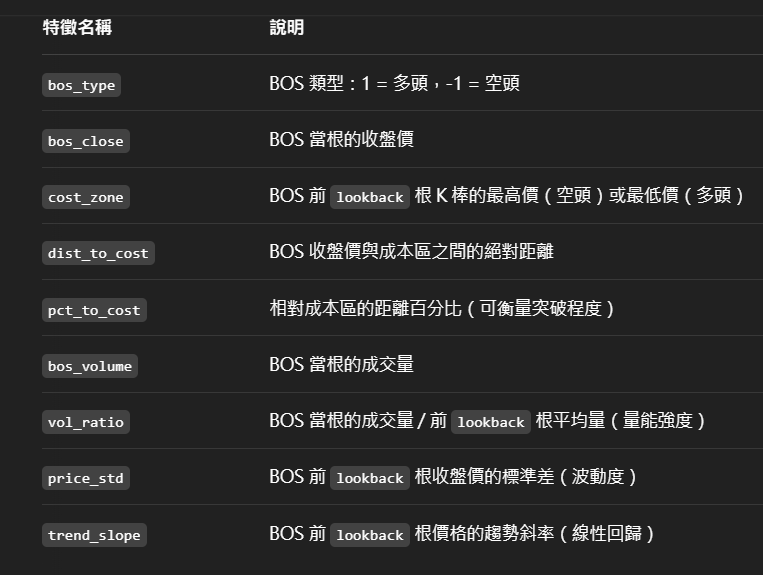

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_curve, roc_auc_score
)
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

y_all = mss_sig.shift(-1).rolling(window=5, min_periods=1).max().fillna(0).astype(int)
y = y_all.iloc[valid_bos_idx].reset_index(drop=True)
X = pd.DataFrame(features).reset_index(drop=True)

# X.to_csv('/content/X_data.csv', index=True)
# y.to_csv('/content/y_data.csv', index=True)
# print(X.describe())

# print("✅ 已將 X 和 y 輸出成 CSV 檔案到 Colab 當前資料夾！")

# 現在 X 跟 y 長度就一樣了！

# 再來才做 mask（移除無限大的資料）
mask = ~X['vol_ratio'].isin([np.inf, -np.inf])
X = X[mask]
y = y[mask]

# preserve time and removed time in X dataframe
time = X['time']
X = X.drop(columns=['time'])



print("X shape:",X.shape)
print("y shape:",y.shape)


X shape: (419, 9)
y shape: (419,)


In [ ]:
# X = pd.DataFrame(features)
# y = pd.Series(labels)

# mask = ~X['vol_ratio'].isin([np.inf, -np.inf])  # 保留不是無限大的行
# # 移除無限大的樣本
# X = X[mask]
# y = y[mask]



移除少許陰性樣本

In [ ]:
# 1. 找出 MSS = 0 的樣本位置（陰性）
neg_indices = y[y == 0].index
pos_indices = y[y == 1].index
print("陰性樣本:",len(neg_indices))
print("陽性樣本:",len(pos_indices))
# 2. 隨機選出要移除的 30 筆陰性樣本
remove_indices = np.random.choice(neg_indices, size=0, replace=False)

# 3. 建立新的 X, y（移除這些 index）
X = X.drop(index=remove_indices)
y = y.drop(index=remove_indices)

陰性樣本: 354
陽性樣本: 65


In [ ]:
neg, pos = np.bincount(y)          # y 是 0 / 1 标签
scale = neg / pos              # 比例 > 1，表示正样本稀少
print(f"neg={neg}, pos={pos},  scale_pos_weight={scale:.2f}")

neg=354, pos=65,  scale_pos_weight=5.45


In [ ]:

model = make_pipeline(
    StandardScaler(),
    XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.01,
        objective = 'binary:logistic',
        gamma = 3,
        scale_pos_weight=scale,
        colsample_bytree = 0.8,
        eval_metric='error',
        random_state=42,
       # grow_policy = 'lossguide',
        #class_weight='balanced'
    )
)

# 五折 Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

threshold = 0.5  # ✅ 新增：可嘗試 0.3 / 0.4 / 0.2
# 初始化
total_cm   = np.zeros((2, 2), dtype=int)
y_true_all = []
y_score_all = []

# Cross‐validation loop
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]  # 正類機率
    y_pred = (y_score >= threshold).astype(int)  # ✅ 新增：改為自訂機率門檻

    # 累加混淆矩陣
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    total_cm += cm

    # 蒐集所有真實標籤與分數
    y_true_all.extend(y_test.tolist())
    y_score_all.extend(y_score.tolist())

# 解構累加後的混淆矩陣
tn, fp, fn, tp = total_cm.ravel()

# 計算各項指標
accuracy  = (tp + tn) / total_cm.sum()
precision = tp / (tp + fp) if tp + fp else 0
recall    = tp / (tp + fn) if tp + fn else 0
f1        = 2 * tp / (2 * tp + fp + fn) if (2*tp + fp + fn) else 0
mcc       = matthews_corrcoef(y_true_all, (np.array(y_score_all) >= 0.5).astype(int))

# 計算 ROC 曲線與 AUC
fpr, tpr, _ = roc_curve(y_true_all, y_score_all)
auc_value   = roc_auc_score(y_true_all, y_score_all)


Aggregated Confusion Matrix:
 [[278  74]
 [ 35  32]]
Accuracy : 0.740
Precision: 0.302
Recall   : 0.478
F1 Score : 0.370
MCC      : 0.225
ROC AUC  : 0.633


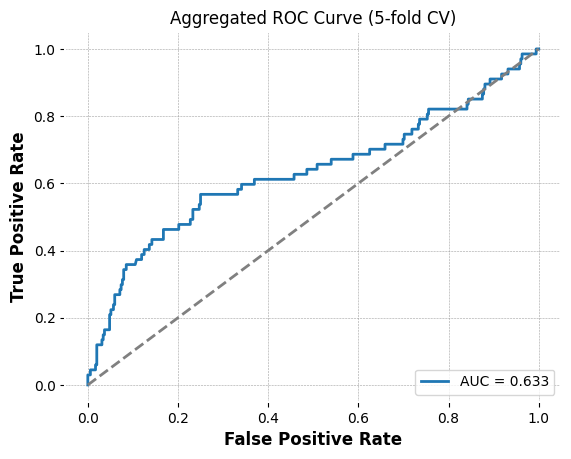

In [ ]:

# 輸出
print("Aggregated Confusion Matrix:\n", total_cm)
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"MCC      : {mcc:.3f}")
print(f"ROC AUC  : {auc_value:.3f}")

# 繪製 ROC 曲線
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_value:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Aggregated ROC Curve (5-fold CV)')
plt.legend(loc='lower right')
plt.show()

# Forward walk validation

Confusion Matrix:
 [[99 42]
 [10  9]]
Accuracy : 0.675
Precision: 0.176
Recall   : 0.474
F1 Score : 0.257
MCC      : 0.122
ROC AUC  : 0.612


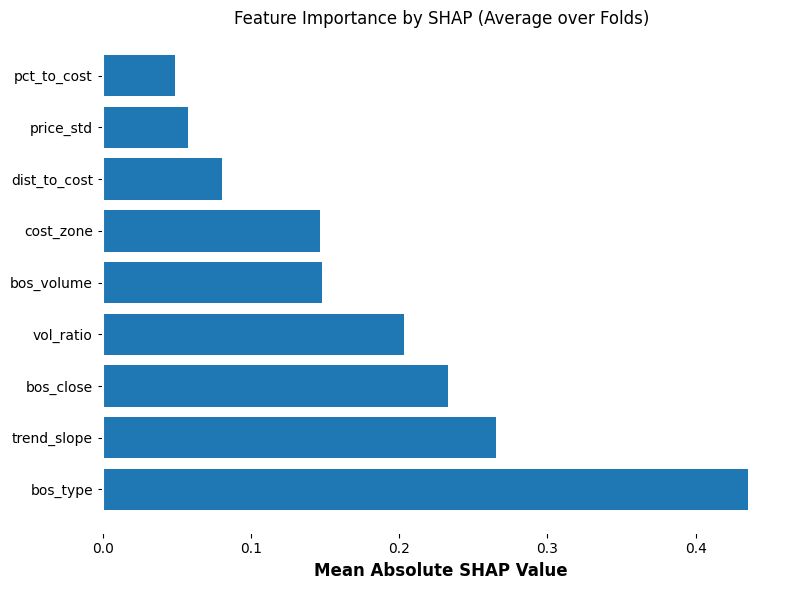

In [ ]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, matthews_corrcoef, roc_curve, roc_auc_score
!pip install shap
import shap

# X, y, scale 已預先定義 (418 筆 BOS 特徵與 MSS 標籤)

# Walk-forward Validation 參數
initial_train_size = 250   # 初始訓練集大小
test_size           = 20    # 每輪測試集大小
threshold           = 0.4  # 機率門檻
n_splits = (len(X) - initial_train_size) // test_size

# 用來儲存每個 fold 的 mean(|shap|)：
feature_names = X.columns.tolist()
n_features    = len(feature_names)
shap_fold_means = np.zeros((n_splits, n_features))


# 初始化累計容器
total_cm   = np.zeros((2, 2), dtype=int)
y_true_all = []
y_score_all = []


# Walk-forward 迴圈
for i in range(n_splits):
    train_end = initial_train_size + i * test_size
    test_end  = train_end + test_size

    X_train, y_train = X.iloc[:train_end],        y.iloc[:train_end]
    X_test,  y_test  = X.iloc[train_end:test_end], y.iloc[train_end:test_end]



    model2 = make_pipeline(
    StandardScaler(),
    XGBClassifier(
        n_estimators=800,
        max_depth=3,
        learning_rate=0.01,
        objective = 'binary:logistic',
        gamma = 3,
        scale_pos_weight=scale,
        colsample_bytree = 0.8,
        eval_metric='error',
        random_state=42,
       # grow_policy = 'lossguide',
        #class_weight='balanced'
    )
    )

    model2.fit(X_train, y_train)

    # 3) SHAP 分析
    #    取出 XGBClassifier 物件
    xgb = model2.named_steps['xgbclassifier']
    explainer = shap.Explainer(xgb, model2.named_steps['standardscaler'].transform(X_train))
    shap_vals = explainer(model2.named_steps['standardscaler'].transform(X_test)).values  # shape=(n_test, n_features)
    # 計算該 fold 每個特徵的 mean(|shap|)
    shap_fold_means[i, :] = np.abs(shap_vals).mean(axis=0)



    # 預測
    y_score = model2.predict_proba(X_test)[:, 1]
    y_pred  = (y_score >= threshold).astype(int)







    # 累加混淆矩陣
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    total_cm += cm



    # 收集所有實際標籤與預測機率
    y_true_all.extend(y_test.tolist())
    y_score_all.extend(y_score.tolist())

# 解構混淆矩陣
tn, fp, fn, tp = total_cm.ravel()

# 5) Fold 之後，對所有 fold 的 mean(|shap|) 做平均
mean_abs_shap_sorted = mean_abs_shap.sort_values(ascending=True)
# 計算各項指標
accuracy  = (tp + tn) / total_cm.sum()
precision = tp / (tp + fp) if tp + fp else 0
recall    = tp / (tp + fn) if tp + fn else 0
f1        = 2 * tp / (2 * tp + fp + fn) if (2*tp + fp + fn) else 0
mcc       = matthews_corrcoef(
    y_true_all,
    (np.array(y_score_all) >= threshold).astype(int)
)
fpr, tpr, _ = roc_curve(y_true_all, y_score_all)
auc_value   = roc_auc_score(y_true_all, y_score_all)

# 輸出結果
print("Confusion Matrix:\n", total_cm)
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"MCC      : {mcc:.3f}")
print(f"ROC AUC  : {auc_value:.3f}")

# 假設 mean_abs_shap 已經是一個 pandas.Series，index 為特徵名稱，values 為平均絕對 SHAP 值

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(mean_abs_shap_sorted.index, mean_abs_shap_sorted.values)

# 把最重要的特徵排到最上面
ax.invert_yaxis()

# 清除背景、格線和軸線
fig.patch.set_facecolor('white')     # 圖片底色
ax.set_facecolor('white')            # 座標軸底色
ax.grid(False)                       # 關閉格線

ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_title("Feature Importance by SHAP (Average over Folds)")

plt.tight_layout()
plt.show()

# 視覺化 workfoward cross validation

In [ ]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def plot_predicted_mss(df, model, X, time, threshold=0.5, title="Model Predicted MSS on K-Line"):
    """
    視覺化模型預測 MSS 標記 + 原始 K 棒
    - df: 原始 K 線資料 (包含 Open/High/Low/Close/Volume)
    - model: 訓練完成的模型 (例如 XGBoost Pipeline)
    - X: 特徵矩陣（索引是 BOS 編號）
    - time: 對應每筆 BOS 特徵的時間戳記（pd.Series）
    - threshold: 分數門檻
    """
    # ────────────────────────────────────────
    # 1) 取得模型預測結果
    y_score = model.predict_proba(X)[:, 1]
    y_pred  = (y_score >= threshold).astype(int)

    # 取得預測 MSS 的時間戳記
    mss_pred_time = time.iloc[y_pred == 1]  # 只取有預測到 MSS 的 BOS 時間

    # ────────────────────────────────────────
    # 2) 建立子圖：K 線 + 成交量
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        row_heights=[0.75, 0.25],
        vertical_spacing=0.02,
        specs=[[{"type": "candlestick"}], [{"type": "bar"}]]
    )

    # ────────────────────────────────────────
    # 3) 畫 K 線
    fig.add_trace(go.Candlestick(
        x=df.index,
        open=df['Open'], high=df['High'],
        low=df['Low'], close=df['Close'],
        name='Price'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 4) 畫模型預測 MSS 標記
    y_coord = []
    for t in mss_pred_time:
        if t not in df.index:
            continue  # 防止找不到對應時間
        if df.loc[t, 'Close'] >= df.loc[t, 'Open']:
            y_coord.append(df.loc[t, 'Low'] * 0.995)
        else:
            y_coord.append(df.loc[t, 'High'] * 1.005)

    fig.add_trace(go.Scatter(
        x=mss_pred_time,
        y=y_coord,
        mode='markers',
        marker_symbol='circle',
        marker_color='#3B82F6',  # 藍色
        marker_size=12,
        marker_line=dict(width=1, color='white'),
        name='Predicted MSS'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 5) 畫成交量
    vol_colors = ['green' if c > o else 'red' for o, c in zip(df['Open'], df['Close'])]
    fig.add_trace(go.Bar(
        x=df.index,
        y=df['Volume'],
        marker_color=vol_colors,
        name='Volume',
        opacity=0.5
    ), row=2, col=1)

    # ────────────────────────────────────────
    # 6) 版面調整
    fig.update_layout(
        title=title,
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=700
    )
    fig.update_yaxes(title_text='Price', row=1, col=1)
    fig.update_yaxes(title_text='Volume', row=2, col=1)

    return fig
fig = plot_predicted_mss(
    df=btc_data_include_time,  # 你的 K 線資料
    model=model2,               # 訓練好的 XGBoost pipeline
    X=X,                       # 特徵資料
    time=time,                 # BOS 對應的時間索引
    threshold=0.5,             # 可自己改 0.3 / 0.4 看效果
    title="BTC 15分鐘 Model 預測 MSS"
)
fig.show()

# forward walk validation predict vs actual MSS Visuialize

In [ ]:
def plot_predicted_mss(df, model, X, time, detected_mss_sig, threshold=0.5, title="Model Predicted MSS vs Detected MSS on K-Line"):
    """
    - df: 原始 K 線資料 (Open/High/Low/Close/Volume)
    - model: 訓練好的分類器 (Pipeline)
    - X: 特徵資料（index對應 BOS點）
    - time: 特徵資料中 BOS 發生時刻 (Series)
    - detected_mss_sig: 用 detect_mss() 偵測出來的 MSS 訊號 (Series，跟 df 同 index)
    - threshold: 自訂分數門檻
    """

    # ────────────────────────────────────────
    # 1) 取得模型預測結果
    y_score = model.predict_proba(X)[:, 1]
    y_pred  = (y_score >= threshold).astype(int)
    mss_pred_time = time.iloc[y_pred == 1]  # 模型預測 MSS 時間點

    # 偵測出來的 MSS (由 detect_mss 函數產生)
    mss_detect_time = detected_mss_sig[detected_mss_sig != 0].index

    # ────────────────────────────────────────
    # 2) 建立子圖
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        row_heights=[0.75, 0.25],
        vertical_spacing=0.02,
        specs=[[{"type": "candlestick"}], [{"type": "bar"}]]
    )

    # ────────────────────────────────────────
    # 3) 畫 K 線
    fig.add_trace(go.Candlestick(
        x=df.index,
        open=df['Open'], high=df['High'],
        low=df['Low'], close=df['Close'],
        name='Price'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 4) 畫模型預測 MSS (藍色圈圈)
    y_coord_pred = []
    for t in mss_pred_time:
        if t not in df.index:
            continue
        y_coord_pred.append(df.loc[t, 'Low'] * 0.995 if df.loc[t, 'Close'] >= df.loc[t, 'Open']
                            else df.loc[t, 'High'] * 1.005)

    fig.add_trace(go.Scatter(
        x=mss_pred_time,
        y=y_coord_pred,
        mode='markers',
        marker_symbol='circle',
        marker_color='#3B82F6',  # 藍色
        marker_size=12,
        marker_line=dict(width=1, color='white'),
        name='Predicted MSS'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 5) 畫 detect_mss MSS (紅色圈圈)
    y_coord_detect = []
    for t in mss_detect_time:
        if t not in df.index:
            continue
        y_coord_detect.append(df.loc[t, 'Low'] * 0.995 if df.loc[t, 'Close'] >= df.loc[t, 'Open']
                               else df.loc[t, 'High'] * 1.005)

    fig.add_trace(go.Scatter(
        x=mss_detect_time,
        y=y_coord_detect,
        mode='markers',
        marker_symbol='circle',
        marker_color='red',  # 紅色
        marker_size=12,
        marker_line=dict(width=1, color='white'),
        name='Detected MSS'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 6) 畫成交量
    vol_colors = ['green' if c > o else 'red' for o, c in zip(df['Open'], df['Close'])]
    fig.add_trace(go.Bar(
        x=df.index,
        y=df['Volume'],
        marker_color=vol_colors,
        name='Volume',
        opacity=0.5
    ), row=2, col=1)

    # ────────────────────────────────────────
    # 7) 版面設定
    fig.update_layout(
        title=title,
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=700
    )
    fig.update_yaxes(title_text='Price', row=1, col=1)
    fig.update_yaxes(title_text='Volume', row=2, col=1)

    return fig

fig = plot_predicted_mss(
    df=btc_data_include_time,         # 你的 K 線資料
    model=model2,                      # 訓練好的模型
    X=X,
    time=time,                         # BOS 對應的時間
    detected_mss_sig=mss_sig,          # detect_mss() 偵測出來的 MSS
    threshold=0.5,                     # 分數門檻
    title="Model Predicted MSS vs Detected MSS"
)
fig.show()


# 視覺化 XGBOOST模型預測MSS VS 真實標註MSS (five fold cross validation)

In [ ]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def plot_predicted_mss(df, model, X, time, threshold=0.5, title="Model Predicted MSS on K-Line"):
    """
    視覺化模型預測 MSS 標記 + 原始 K 棒
    - df: 原始 K 線資料 (包含 Open/High/Low/Close/Volume)
    - model: 訓練完成的模型 (例如 XGBoost Pipeline)
    - X: 特徵矩陣（索引是 BOS 編號）
    - time: 對應每筆 BOS 特徵的時間戳記（pd.Series）
    - threshold: 分數門檻
    """
    # ────────────────────────────────────────
    # 1) 取得模型預測結果
    y_score = model.predict_proba(X)[:, 1]
    y_pred  = (y_score >= threshold).astype(int)

    # 取得預測 MSS 的時間戳記
    mss_pred_time = time.iloc[y_pred == 1]  # 只取有預測到 MSS 的 BOS 時間

    # ────────────────────────────────────────
    # 2) 建立子圖：K 線 + 成交量
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        row_heights=[0.75, 0.25],
        vertical_spacing=0.02,
        specs=[[{"type": "candlestick"}], [{"type": "bar"}]]
    )

    # ────────────────────────────────────────
    # 3) 畫 K 線
    fig.add_trace(go.Candlestick(
        x=df.index,
        open=df['Open'], high=df['High'],
        low=df['Low'], close=df['Close'],
        name='Price'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 4) 畫模型預測 MSS 標記
    y_coord = []
    for t in mss_pred_time:
        if t not in df.index:
            continue  # 防止找不到對應時間
        if df.loc[t, 'Close'] >= df.loc[t, 'Open']:
            y_coord.append(df.loc[t, 'Low'] * 0.995)
        else:
            y_coord.append(df.loc[t, 'High'] * 1.005)

    fig.add_trace(go.Scatter(
        x=mss_pred_time,
        y=y_coord,
        mode='markers',
        marker_symbol='circle',
        marker_color='#3B82F6',  # 藍色
        marker_size=12,
        marker_line=dict(width=1, color='white'),
        name='Predicted MSS'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 5) 畫成交量
    vol_colors = ['green' if c > o else 'red' for o, c in zip(df['Open'], df['Close'])]
    fig.add_trace(go.Bar(
        x=df.index,
        y=df['Volume'],
        marker_color=vol_colors,
        name='Volume',
        opacity=0.5
    ), row=2, col=1)

    # ────────────────────────────────────────
    # 6) 版面調整
    fig.update_layout(
        title=title,
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=700
    )
    fig.update_yaxes(title_text='Price', row=1, col=1)
    fig.update_yaxes(title_text='Volume', row=2, col=1)

    return fig
fig = plot_predicted_mss(
    df=btc_data_include_time,  # 你的 K 線資料
    model=model,               # 訓練好的 XGBoost pipeline
    X=X,                       # 特徵資料
    time=time,                 # BOS 對應的時間索引
    threshold=0.5,             # 可自己改 0.3 / 0.4 看效果
    title="BTC 15分鐘 Model 預測 MSS"
)
fig.show()



In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

def plot_predicted_mss(df, model, X, time, detected_mss_sig, threshold=0.5, title="Model Predicted MSS vs Detected MSS on K-Line"):
    """
    - df: 原始 K 線資料 (Open/High/Low/Close/Volume)
    - model: 訓練好的分類器 (Pipeline)
    - X: 特徵資料（index對應 BOS點）
    - time: 特徵資料中 BOS 發生時刻 (Series)
    - detected_mss_sig: 用 detect_mss() 偵測出來的 MSS 訊號 (Series，跟 df 同 index)
    - threshold: 自訂分數門檻
    """

    # ────────────────────────────────────────
    # 1) 取得模型預測結果
    y_score = model.predict_proba(X)[:, 1]
    y_pred  = (y_score >= threshold).astype(int)
    mss_pred_time = time.iloc[y_pred == 1]  # 模型預測 MSS 時間點

    # 偵測出來的 MSS (由 detect_mss 函數產生)
    mss_detect_time = detected_mss_sig[detected_mss_sig != 0].index

    # ────────────────────────────────────────
    # 2) 建立子圖
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        row_heights=[0.75, 0.25],
        vertical_spacing=0.02,
        specs=[[{"type": "candlestick"}], [{"type": "bar"}]]
    )

    # ────────────────────────────────────────
    # 3) 畫 K 線
    fig.add_trace(go.Candlestick(
        x=df.index,
        open=df['Open'], high=df['High'],
        low=df['Low'], close=df['Close'],
        name='Price'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 4) 畫模型預測 MSS (藍色圈圈)
    y_coord_pred = []
    for t in mss_pred_time:
        if t not in df.index:
            continue
        y_coord_pred.append(df.loc[t, 'Low'] * 0.995 if df.loc[t, 'Close'] >= df.loc[t, 'Open']
                            else df.loc[t, 'High'] * 1.005)

    fig.add_trace(go.Scatter(
        x=mss_pred_time,
        y=y_coord_pred,
        mode='markers',
        marker_symbol='circle',
        marker_color='#3B82F6',  # 藍色
        marker_size=12,
        marker_line=dict(width=1, color='white'),
        name='Predicted MSS'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 5) 畫 detect_mss MSS (紅色圈圈)
    y_coord_detect = []
    for t in mss_detect_time:
        if t not in df.index:
            continue
        y_coord_detect.append(df.loc[t, 'Low'] * 0.995 if df.loc[t, 'Close'] >= df.loc[t, 'Open']
                               else df.loc[t, 'High'] * 1.005)

    fig.add_trace(go.Scatter(
        x=mss_detect_time,
        y=y_coord_detect,
        mode='markers',
        marker_symbol='circle',
        marker_color='red',  # 紅色
        marker_size=12,
        marker_line=dict(width=1, color='white'),
        name='Detected MSS'
    ), row=1, col=1)

    # ────────────────────────────────────────
    # 6) 畫成交量
    vol_colors = ['green' if c > o else 'red' for o, c in zip(df['Open'], df['Close'])]
    fig.add_trace(go.Bar(
        x=df.index,
        y=df['Volume'],
        marker_color=vol_colors,
        name='Volume',
        opacity=0.5
    ), row=2, col=1)

    # ────────────────────────────────────────
    # 7) 版面設定
    fig.update_layout(
        title=title,
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=700
    )
    fig.update_yaxes(title_text='Price', row=1, col=1)
    fig.update_yaxes(title_text='Volume', row=2, col=1)

    return fig

fig = plot_predicted_mss(
    df=btc_data_include_time,         # 你的 K 線資料
    model=model,                      # 訓練好的模型
    X=X,
    time=time,                         # BOS 對應的時間
    detected_mss_sig=mss_sig,          # detect_mss() 偵測出來的 MSS
    threshold=0.5,                     # 分數門檻
    title="Model Predicted MSS vs Detected MSS"
)
fig.show()


# version 2 加上 smote

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:22:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:22:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:22:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:22:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:22:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




Aggregated Confusion Matrix:
 [[287  58]
 [ 44  21]]
Accuracy : 0.751
Precision: 0.266
Recall   : 0.323
F1 Score : 0.292
MCC      : 0.144
ROC AUC  : 0.628


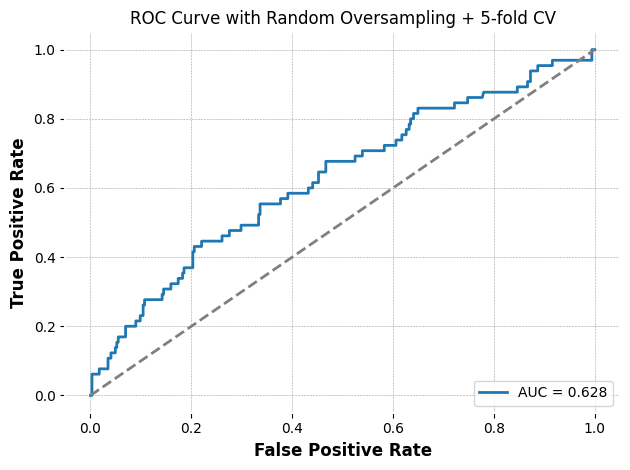

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, matthews_corrcoef, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# 假設你已經有 X, y，並移除了 vol_ratio 為 inf 的樣本
mask = ~X['vol_ratio'].isin([np.inf, -np.inf])
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
threshold = 0.5

total_cm = np.zeros((2, 2), dtype=int)
y_true_all = []
y_score_all = []

for train_idx, test_idx in skf.split(X, y):
    # 1. 分割訓練／測試集
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # 2. 手動隨機過採樣：將少數類 (y==1) 重複抽樣到跟 majority 同量
    pos_idx = y_train[y_train == 1].index
    neg_idx = y_train[y_train == 0].index
    n_neg = len(neg_idx)
    # 重採樣正類 index
    up_idx = np.random.choice(pos_idx, size=n_neg, replace=True)
    resample_idx = np.concatenate([neg_idx, up_idx])
    X_train_res = X_train.loc[resample_idx].reset_index(drop=True)
    y_train_res = y_train.loc[resample_idx].reset_index(drop=True)

    # 3. 建 pipeline：標準化 + XGBoost
    model = make_pipeline(
        StandardScaler(),
        XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.01,
            objective='binary:logistic',
            gamma=3,
            scale_pos_weight=1,    # 手動平衡後不需要再加權
            colsample_bytree=0.8,
            eval_metric='auc',
            random_state=42,
            use_label_encoder=False
        )
    )

    # 4. 訓練並預測
    model.fit(X_train_res, y_train_res)
    y_score = model.predict_proba(X_test)[:, 1]
    y_pred = (y_score >= threshold).astype(int)

    # 5. 累積混淆矩陣和分數
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    total_cm += cm
    y_true_all.extend(y_test)
    y_score_all.extend(y_score)

# 解構累積混淆矩陣
tn, fp, fn, tp = total_cm.ravel()

# 計算各項指標
accuracy  = (tp + tn) / total_cm.sum()
precision = tp / (tp + fp) if tp + fp else 0
recall    = tp / (tp + fn) if tp + fn else 0
f1        = 2 * tp / (2 * tp + fp + fn) if (2*tp + fp + fn) else 0
mcc       = matthews_corrcoef(y_true_all, (np.array(y_score_all) >= threshold).astype(int))
auc_value = roc_auc_score(y_true_all, y_score_all)

print("Aggregated Confusion Matrix:\n", total_cm)
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"MCC      : {mcc:.3f}")
print(f"ROC AUC  : {auc_value:.3f}")

# 繪製 ROC 曲線
fpr, tpr, _ = roc_curve(y_true_all, y_score_all)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_value:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Random Oversampling + 5-fold CV')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.4 MB/s eta 0:00:00
Aggregated Confusion Matrix:
 [[331  35]
 [ 28  16]]
Accuracy : 0.846
Precision: 0.314
Recall   : 0.364
F1 Score : 0.337
MCC      : 0.251
ROC AUC  : 0.669


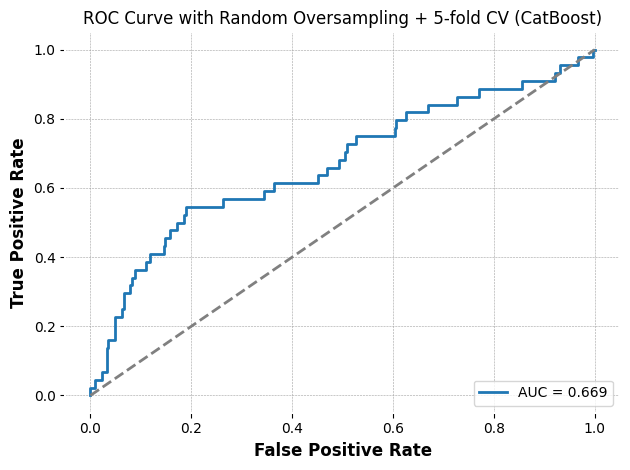

In [ ]:
import numpy as np
import pandas as pd
!pip install catboost

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, matthews_corrcoef, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# 假設你已經有 X, y，並移除了 vol_ratio 為 inf 的樣本
mask = ~X['vol_ratio'].isin([np.inf, -np.inf])
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
threshold = 0.5

total_cm = np.zeros((2, 2), dtype=int)
y_true_all = []
y_score_all = []

for train_idx, test_idx in skf.split(X, y):
    # 1. 分割訓練／測試集
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # 2. 手動隨機過採樣：將少數類 (y==1) 重複抽樣到跟 majority 同量
    pos_idx = y_train[y_train == 1].index
    neg_idx = y_train[y_train == 0].index
    n_neg = len(neg_idx)
    up_idx = np.random.choice(pos_idx, size=n_neg, replace=True)
    resample_idx = np.concatenate([neg_idx, up_idx])
    X_train_res = X_train.loc[resample_idx].reset_index(drop=True)
    y_train_res = y_train.loc[resample_idx].reset_index(drop=True)

    # 3. 建 pipeline：標準化 + CatBoost
    model = make_pipeline(
        StandardScaler(),
        CatBoostClassifier(
            iterations=500,
            depth=5,
            learning_rate=0.01,
            eval_metric='AUC',
            random_seed=42,
            verbose=0
        )
    )

    # 4. 訓練並預測
    model.fit(X_train_res, y_train_res)
    y_score = model.predict_proba(X_test)[:, 1]
    y_pred = (y_score >= threshold).astype(int)

    # 5. 累積混淆矩陣和分數
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    total_cm += cm
    y_true_all.extend(y_test)
    y_score_all.extend(y_score)

# 解構累積混淆矩陣
tn, fp, fn, tp = total_cm.ravel()

# 計算各項指標
accuracy  = (tp + tn) / total_cm.sum()
precision = tp / (tp + fp) if tp + fp else 0
recall    = tp / (tp + fn) if tp + fn else 0
f1        = 2 * tp / (2 * tp + fp + fn) if (2*tp + fp + fn) else 0
mcc       = matthews_corrcoef(y_true_all, (np.array(y_score_all) >= threshold).astype(int))
auc_value = roc_auc_score(y_true_all, y_score_all)

print("Aggregated Confusion Matrix:\n", total_cm)
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"MCC      : {mcc:.3f}")
print(f"ROC AUC  : {auc_value:.3f}")

# 繪製 ROC 曲線
fpr, tpr, _ = roc_curve(y_true_all, y_score_all)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_value:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Random Oversampling + 5-fold CV (CatBoost)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# 貝葉斯分類器

Confusion Matrix:
 [[306  60]
 [ 29  15]]
Precision: 0.200
Recall   : 0.341
F1 Score : 0.252
MCC      : 0.142
ROC AUC  : 0.619


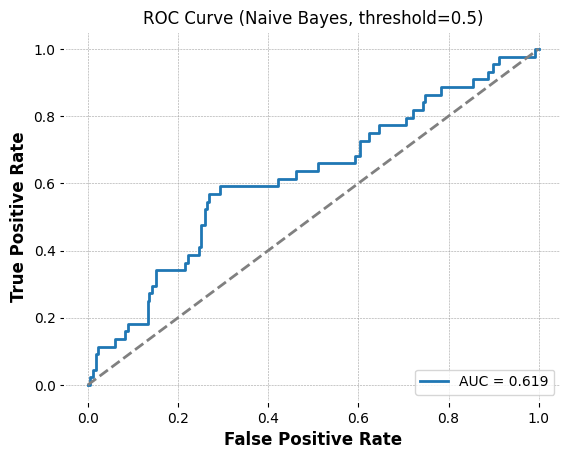

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt

# 構建 Gaussian Naive Bayes 模型（含標準化）
model = make_pipeline(
    StandardScaler(),
    GaussianNB()
)

# 五折交叉驗證
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
threshold = 0.5  # 可手動調整，如 0.4, 0.3...

# 初始化累計變數
total_cm = np.zeros((2, 2), dtype=int)
y_true_all, y_score_all, y_pred_all = [], [], []

# 執行交叉驗證
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:, 1]
    y_pred = (y_score >= threshold).astype(int)

    total_cm += confusion_matrix(y_test, y_pred, labels=[0, 1])
    y_true_all.extend(y_test.tolist())
    y_score_all.extend(y_score.tolist())
    y_pred_all.extend(y_pred.tolist())  # ← 加入預測標籤

# 計算各項指標
tn, fp, fn, tp = total_cm.ravel()
precision = precision_score(y_true_all, y_pred_all)
recall    = recall_score(y_true_all, y_pred_all)
f1        = f1_score(y_true_all, y_pred_all)
mcc       = matthews_corrcoef(y_true_all, y_pred_all)
auc       = roc_auc_score(y_true_all, y_score_all)
fpr, tpr, _ = roc_curve(y_true_all, y_score_all)

# 輸出結果
print("Confusion Matrix:\n", total_cm)
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"MCC      : {mcc:.3f}")
print(f"ROC AUC  : {auc:.3f}")

# 繪製 ROC 曲線
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (Naive Bayes, threshold={threshold})')
plt.legend(loc='lower right')
plt.show()


貝葉斯 + SMOTE

Aggregated Confusion Matrix:
 [[183 183]
 [ 16  28]]
Precision: 0.133
Recall   : 0.636
F1 Score : 0.220
MCC      : 0.084
ROC AUC  : 0.640


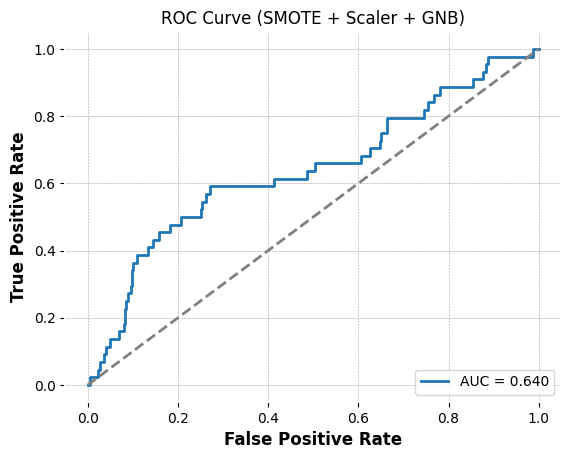

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score, roc_curve
)
import numpy as np
import matplotlib.pyplot as plt

# 假設 X, y 已在環境中準備好

# 1. SMOTE + Scaler + GNB 參數
smote     = SMOTE(random_state=42)
scaler    = StandardScaler()
gnb       = GaussianNB()
threshold = 0.5  # 依需求可調整

# 2. 五折分層 CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. 初始化累計
total_cm   = np.zeros((2, 2), dtype=int)
y_true_all = []
y_score_all = []
y_pred_all  = []

# 4. 迴圈每折
for train_idx, test_idx in skf.split(X, y):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]

    # 4a. 只在訓練集上做 SMOTE
    X_res, y_res = smote.fit_resample(X_train, y_train)

    # 4b. 標準化
    X_res_scaled = scaler.fit_transform(X_res)
    X_test_scaled= scaler.transform(X_test)

    # 4c. 訓練 & 預測
    gnb.fit(X_res_scaled, y_res)
    y_score = gnb.predict_proba(X_test_scaled)[:, 1]
    y_pred  = (y_score >= threshold).astype(int)

    # 4d. 累加結果
    total_cm   += confusion_matrix(y_test, y_pred, labels=[0,1])
    y_true_all.extend(y_test.tolist())
    y_score_all.extend(y_score.tolist())
    y_pred_all.extend(y_pred.tolist())

# 5. 解構混淆矩陣與計算指標
tn, fp, fn, tp = total_cm.ravel()
precision = precision_score(y_true_all, y_pred_all)
recall    = recall_score(y_true_all, y_pred_all)
f1        = f1_score(y_true_all, y_pred_all)
mcc       = matthews_corrcoef(y_true_all, y_pred_all)
auc       = roc_auc_score(y_true_all, y_score_all)
fpr, tpr, _ = roc_curve(y_true_all, y_score_all)

# 6. 列印指標
print("Aggregated Confusion Matrix:\n", total_cm)
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"MCC      : {mcc:.3f}")
print(f"ROC AUC  : {auc:.3f}")

# 7. 繪製 ROC 曲線
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (SMOTE + Scaler + GNB)')
plt.legend(loc='lower right')
plt.show()


# 貝葉斯特徵握正規畫

最佳 Threshold = 0.521, 對應 F1 Score = 0.306


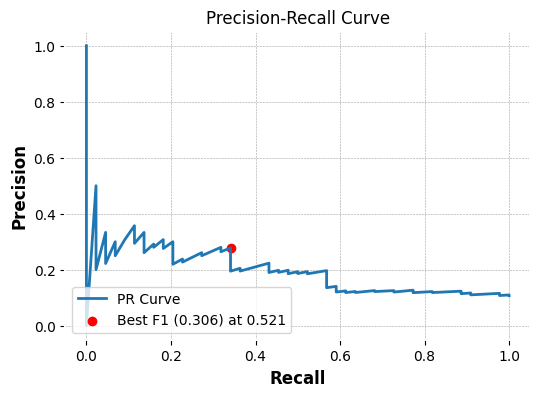

Confusion Matrix at Best Threshold:
[[327  39]
 [ 29  15]]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix
# 1. Log 轉換可能偏態的特徵
log_features = ["bos_volume", "dist_to_cost", "cost_zone"]
X_log = X.copy()
for feat in log_features:
    X_log[feat] = np.log1p(X_log[feat])

# 2. 標準化 + GaussianNB，使用 cross_val_predict 取機率
pipeline = make_pipeline(StandardScaler(), GaussianNB())
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(pipeline, X_log, y, cv=cv, method="predict_proba")[:, 1]

# 3. 計算 Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y, y_scores)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# 4. 輸出最佳閾值與 F1
print(f"最佳 Threshold = {best_thresh:.3f}, 對應 F1 Score = {best_f1:.3f}")

# 5. 畫 PR Curve
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label="PR Curve")
plt.scatter(recall[best_idx], precision[best_idx], color="red",
            label=f"Best F1 ({best_f1:.3f}) at {best_thresh:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# 6. 在最佳閾值下計算混淆矩陣
y_pred_best = (y_scores >= best_thresh).astype(int)
cm = confusion_matrix(y, y_pred_best)
print("Confusion Matrix at Best Threshold:")
print(cm)

# xgboot + 貝葉斯 + 多鍾模型


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:00:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:00:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:00:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:00:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:00:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[09:00:46] WARNING: /workspace

=== XGB ===
Threshold: 0.49327675
Confusion Matrix:
 [[323  43]
 [ 27  17]]
Precision: 0.283, Recall: 0.386, F1: 0.327, MCC: 0.235, ROC AUC: 0.639

=== LR ===
Threshold: 0.7294280421111061
Confusion Matrix:
 [[344  22]
 [ 28  16]]
Precision: 0.421, Recall: 0.364, F1: 0.390, MCC: 0.324, ROC AUC: 0.725

=== GNB ===
Threshold: 0.3450282626019566
Confusion Matrix:
 [[268  98]
 [ 19  25]]
Precision: 0.203, Recall: 0.568, F1: 0.299, MCC: 0.203, ROC AUC: 0.619

=== Ensemble ===
Threshold: 0.6148316042174898
Confusion Matrix:
 [[344  22]
 [ 29  15]]
Precision: 0.405, Recall: 0.341, F1: 0.370, MCC: 0.303, ROC AUC: 0.688



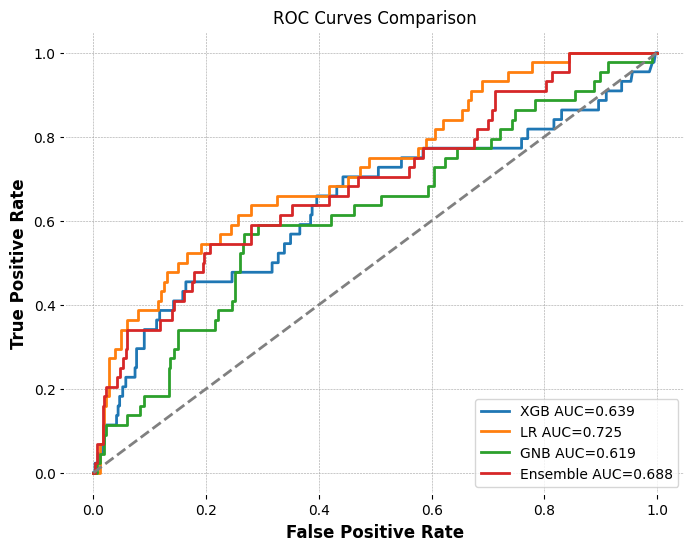

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve, confusion_matrix, precision_score,
    recall_score, f1_score, matthews_corrcoef, roc_auc_score, roc_curve
)


# 1. 計算 scale_pos_weight
neg, pos = np.bincount(y)
scale = neg / pos

# 2. 定義各模型 pipeline (XGB, LR, GNB)
models = {
    'XGB': make_pipeline(
        StandardScaler(),
        XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.01,
            objective='binary:logistic',
            gamma=3,
            scale_pos_weight=scale,    # 手動平衡後不需要再加權
            colsample_bytree=0.8,
            eval_metric='auc',
            random_state=42,
            use_label_encoder=False
        )
    ),
    'LR': make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    ),
    'GNB': make_pipeline(
        StandardScaler(),
        GaussianNB()
    )
}

# 3. 5-fold 分層 CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    # 預測正類機率
    y_scores = cross_val_predict(model, X, y, cv=skf, method='predict_proba')[:, 1]
    # Precision-Recall 曲線與最佳 threshold
    precision, recall, thresholds = precision_recall_curve(y, y_scores)
    f1_vals = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_vals)
    best_thr = thresholds[best_idx]
    # 在最佳 threshold 下計算指標
    y_pred = (y_scores >= best_thr).astype(int)
    cm = confusion_matrix(y, y_pred, labels=[0,1])
    results[name] = {
        'threshold': best_thr,
        'cm': cm,
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
        'mcc': matthews_corrcoef(y, y_pred),
        'roc_auc': roc_auc_score(y, y_scores),
        'fpr': roc_curve(y, y_scores)[0],
        'tpr': roc_curve(y, y_scores)[1]
    }

# 4. 建立 VotingClassifier（軟投票）
ensemble = VotingClassifier(
    estimators=[(n, m) for n, m in models.items()],
    voting='soft'
)
y_scores = cross_val_predict(ensemble, X, y, cv=skf, method='predict_proba')[:, 1]
precision_e, recall_e, thresholds_e = precision_recall_curve(y, y_scores)
f1_e = 2 * precision_e * recall_e / (precision_e + recall_e + 1e-8)
best_idx_e = np.argmax(f1_e)
best_thr_e = thresholds_e[best_idx_e]
y_pred_e = (y_scores >= best_thr_e).astype(int)
cm_e = confusion_matrix(y, y_pred_e, labels=[0,1])
results['Ensemble'] = {
    'threshold': best_thr_e,
    'cm': cm_e,
    'precision': precision_score(y, y_pred_e),
    'recall': recall_score(y, y_pred_e),
    'f1': f1_score(y, y_pred_e),
    'mcc': matthews_corrcoef(y, y_pred_e),
    'roc_auc': roc_auc_score(y, y_scores),
    'fpr': roc_curve(y, y_scores)[0],
    'tpr': roc_curve(y, y_scores)[1]
}

# 5. 輸出比較結果
for name, res in results.items():
    print(f"=== {name} ===")
    print("Threshold:", res['threshold'])
    print("Confusion Matrix:\n", res['cm'])
    print(f"Precision: {res['precision']:.3f}, Recall: {res['recall']:.3f}, "
          f"F1: {res['f1']:.3f}, MCC: {res['mcc']:.3f}, ROC AUC: {res['roc_auc']:.3f}\n")

# 6. 繪製 ROC 曲線比較
plt.figure(figsize=(8,6))
for name, res in results.items():
    plt.plot(res['fpr'], res['tpr'], label=f"{name} AUC={res['roc_auc']:.3f}")
plt.plot([0,1], [0,1], '--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    precision_recall_curve, confusion_matrix, precision_score,
    recall_score, f1_score, matthews_corrcoef, roc_auc_score
)

# ─────────── 假設 X, y 已經準備好 ───────────
# X: pandas.DataFrame 特徵矩陣
# y: pandas.Series 標籤（0/1）
# 例如：
# X = pd.read_csv('features.csv', index_col=0)
# y = pd.read_csv('labels.csv', index_col=0)['label']

# ─────────── 1. 定義各模型 pipeline ───────────
neg, pos = np.bincount(y)
scale = neg / pos

models = {
    'XGB': make_pipeline(
        StandardScaler(),
        XGBClassifier(
            n_estimators=500,
            max_depth=5,
            learning_rate=0.01,
            objective='binary:logistic',
            gamma=3,
            scale_pos_weight=scale,    # 手動平衡後不需要再加權
            colsample_bytree=0.8,
            eval_metric='auc',
            random_state=42,
            use_label_encoder=False
        )   # closes XGBClassifier
    ),      # closes make_pipeline
    'LR': make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    ),
    'GNB': make_pipeline(
        StandardScaler(),
        GaussianNB()
    )
}

# ─────────── 2. 5-fold CV 计算各模型最佳 F1 与 threshold ───────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    # 预测正类概率
    y_scores = cross_val_predict(model, X, y, cv=skf, method='predict_proba')[:, 1]
    # Precision-Recall 曲线
    precision, recall, thresholds = precision_recall_curve(y, y_scores)
    f1_vals = 2 * precision * recall / (precision + recall + 1e-8)
    best_idx = np.nanargmax(f1_vals)
    best_thr = thresholds[best_idx]
    # 生成预测
    y_pred = (y_scores >= best_thr).astype(int)
    cm = confusion_matrix(y, y_pred, labels=[0,1])
    results[name] = {
        'f1': f1_score(y, y_pred),
        'threshold': best_thr,
        'cm': cm,
        'precision': precision_score(y, y_pred),
        'recall': recall_score(y, y_pred),
        'mcc': matthews_corrcoef(y, y_pred),
        'roc_auc': roc_auc_score(y, y_scores)
    }

# ─────────── 3. 构建加权软投票 Ensemble ───────────
weights = [results[m]['f1'] for m in ['XGB','LR','GNB']]
ensemble = VotingClassifier(
    estimators=[(m, models[m]) for m in ['XGB','LR','GNB']],
    voting='soft',
    weights=weights
)

# ─────────── 4. 交叉验证 Ensemble，并 threshold tuning ───────────
y_scores = cross_val_predict(ensemble, X, y, cv=skf, method='predict_proba')[:, 1]
precision_e, recall_e, thresholds_e = precision_recall_curve(y, y_scores)
f1_e = 2 * precision_e * recall_e / (precision_e + recall_e + 1e-8)
best_idx_e = np.nanargmax(f1_e)
best_thr_e = thresholds_e[best_idx_e]
y_pred_e = (y_scores >= best_thr_e).astype(int)
cm_e = confusion_matrix(y, y_pred_e, labels=[0,1])

# ─────────── 5. 输出 Ensemble 结果 ───────────
print("=== Weighted Voting Ensemble (Soft) ===")
print("Model F1 Weights:", dict(zip(['XGB','LR','GNB'], weights)))
print(f"Best Threshold: {best_thr_e:.3f}")
print("Confusion Matrix:\n", cm_e)
print(f"Precision: {precision_score(y, y_pred_e):.3f}")
print(f"Recall   : {recall_score(y, y_pred_e):.3f}")
print(f"F1 Score : {f1_score(y, y_pred_e):.3f}")
print(f"MCC      : {matthews_corrcoef(y, y_pred_e):.3f}")
print(f"ROC AUC  : {roc_auc_score(y, y_scores):.3f}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[14:03:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[14:03:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[14:03:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[14:03:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[14:03:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[14:03:37] WARNING: /workspace

=== Weighted Voting Ensemble (Soft) ===
Model F1 Weights: {'XGB': 0.3407707910750507, 'LR': 0.3615023474178404, 'GNB': 0.36074270557029176}
Best Threshold: 0.323
Confusion Matrix:
 [[ 89 239]
 [ 17  67]]
Precision: 0.219
Recall   : 0.798
F1 Score : 0.344
MCC      : 0.064
ROC AUC  : 0.508
